# Period on Period Plot Gallery

Period-on-period plots overlay multiple time windows from the same series on a single chart, all aligned to a shared starting point. They turn questions like *is this June running ahead of last June* or *is this Black Friday week tracking past peaks* into a single glance.

Period-on-period plots excel at:
- **Year-on-year comparisons**: stack identical calendar windows from successive years to read seasonal performance
- **Campaign analysis**: overlay matched promo weeks across runs to see whether the latest beat its predecessors
- **Event-impact reads**: compare the days around a launch, outage, or holiday across multiple instances
- **Pattern recognition**: spot whether a daily or intra-week rhythm holds steady across periods

The newest period draws darkest, thickest, and on top, with older periods receding into lighter shades and thinner lines, so the focus reads instantly even with four overlapping series.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from openretailscience.plots import period_on_period
from openretailscience.plots.styles.graph_utils import set_axis_shorthand
from openretailscience.utils.date import find_overlapping_periods

In [ ]:
# Hand-crafted demo datasets shared across the gallery examples.

# 1) Daily store revenue across June 2022, 2023, 2024.
# Per-year baselines reflect roughly 16% and 14% YoY growth. Weekends carry
# a ~10% uplift over weekdays, and each day gets reproducible noise from a
# seeded RNG so the lines wobble realistically instead of stamping out an
# identical weekday-plateau / weekend-step pattern. Each year is rescaled
# so its mean exactly matches the design baseline, keeping the headline
# YoY ratios true to within a rounding.
_june_year_baseline = {2022: 50_000, 2023: 58_000, 2024: 66_000}
_WEEKEND_UPLIFT = 1.10
_WEEKDAY_SHARE = 5 / 7
_WEEKEND_SHARE = 2 / 7
_june_rng = np.random.default_rng(7)
_june_per_year_frames = []
for year, baseline in _june_year_baseline.items():
    days = pd.date_range(f"{year}-06-01", f"{year}-06-30", freq="D")
    base_factor = np.where(days.weekday >= 5, _WEEKEND_UPLIFT, 1.0)
    daily_noise = _june_rng.normal(0, 0.04, size=len(days))
    raw = baseline * base_factor * (1 + daily_noise)
    target_mean = baseline * (_WEEKDAY_SHARE + _WEEKEND_SHARE * _WEEKEND_UPLIFT)
    daily_revenue = (raw * target_mean / raw.mean()).round(0)
    _june_per_year_frames.append(
        pd.DataFrame({"date": days, "daily_revenue": daily_revenue}),
    )
june_revenue = pd.concat(_june_per_year_frames, ignore_index=True)

# 2) Daily revenue for the seven-day window Nov 24-30 of four successive
# years. Per-year baselines step up year on year. A shared intra-window
# shape (small mid-week dip, sharp spike on day 5, weekend tail) is applied
# positionally to each year so the realigned lines track each other, then
# per-day noise from a seeded RNG breaks the strict parallelism so the
# lines wobble independently year on year.
_bf_year_baseline = {2021: 80_000, 2022: 95_000, 2023: 110_000, 2024: 130_000}
_bf_intra_window_factor = np.array(
    [0.95, 0.90, 0.85, 0.55, 1.50, 1.30, 1.05],  # day 0..6 within the window
)
_bf_rng = np.random.default_rng(11)
_bf_per_year_frames = [
    pd.DataFrame(
        {
            "date": pd.date_range(f"{year}-11-24", f"{year}-11-30", freq="D"),
            "daily_revenue": (baseline * _bf_intra_window_factor * (1 + _bf_rng.normal(0, 0.05, size=7))).round(0),
        },
    )
    for year, baseline in _bf_year_baseline.items()
]
bf_week_revenue = pd.concat(_bf_per_year_frames, ignore_index=True)

# 3) Monthly store revenue across an awkward 2.5-year window, Jan 2022
# through June 2024. The shape lets `find_overlapping_periods` carve the
# data into two 18-month windows that overlap by 18 months once realigned.
# A linear trend takes the mean from $1.5M to $2.0M across the span, with
# seeded noise giving each month some month-to-month variation.
_monthly_dates = pd.date_range("2022-01-01", "2024-06-01", freq="MS")
_monthly_baseline = np.linspace(1_500_000, 2_000_000, num=len(_monthly_dates))
_monthly_rng = np.random.default_rng(7)
_monthly_noise = _monthly_rng.normal(0, 0.04, size=len(_monthly_dates))
monthly_revenue = pd.DataFrame(
    {
        "date": _monthly_dates,
        "monthly_revenue": (_monthly_baseline * (1 + _monthly_noise)).round(0),
    },
)

## Two Period Comparison

The basic shape: pass `periods` as a list of `(start, end)` tuples. The function pulls each window, realigns it to the start of the first period in the list, and overlays them. Use this when the question is whether *this* window is running ahead, behind, or in step with the prior one.

---

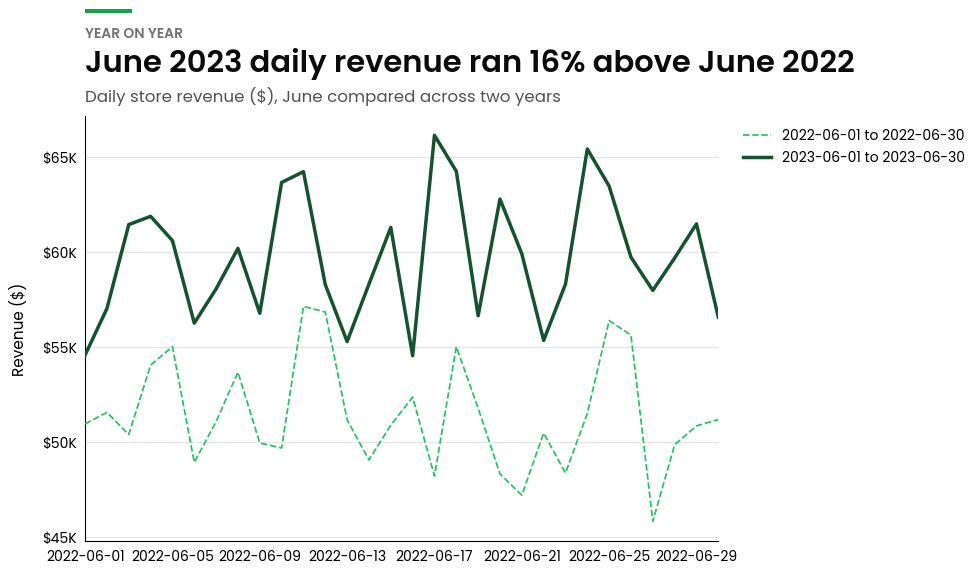

In [ ]:
ax = period_on_period.plot(
    june_revenue,
    x_col="date",
    value_col="daily_revenue",
    periods=[
        ("2022-06-01", "2022-06-30"),
        ("2023-06-01", "2023-06-30"),
    ],
    eyebrow="Year on year",
    title="June 2023 daily revenue ran 16% above June 2022",
    subtitle="Daily store revenue ($), June compared across two years",
    y_label="Revenue ($)",
    figsize=(10, 6),
    move_legend_outside=True,
)
set_axis_shorthand(ax.yaxis, prefix="$")
plt.show()

## Multiple Period Comparison

Pass three or more periods to read the full multi-year picture in one chart. The colors, line weights, and z-order all ramp together: the newest period sits darkest and thickest on top of the stack, the oldest sits lightest and thinnest underneath. The reader's eye lands on the latest period first, then walks back through history.

---

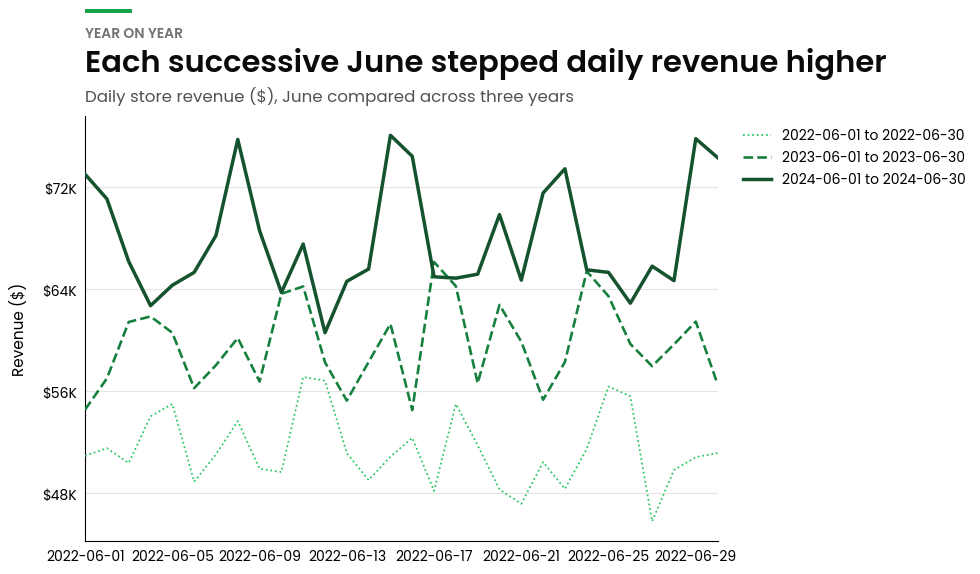

In [ ]:
ax = period_on_period.plot(
    june_revenue,
    x_col="date",
    value_col="daily_revenue",
    periods=[
        ("2022-06-01", "2022-06-30"),
        ("2023-06-01", "2023-06-30"),
        ("2024-06-01", "2024-06-30"),
    ],
    eyebrow="Year on year",
    title="Each successive June stepped daily revenue higher",
    subtitle="Daily store revenue ($), June compared across three years",
    y_label="Revenue ($)",
    figsize=(10, 6),
    move_legend_outside=True,
)
set_axis_shorthand(ax.yaxis, prefix="$")
plt.show()

## Build Periods with `find_overlapping_periods`

`find_overlapping_periods` is for the case where your data covers an awkward span, like 30 months from January 2022 through June 2024. Pass it the start and end of your data and it returns one tuple per starting year, each running from `(year, start.mm-dd)` to `(year + 1, end.mm-dd)`. From 2.5 years of data, you get two 18-month windows that overlap completely once realigned. Doing the same by hand means counting months, and redoing the list every time the data range moves.

---

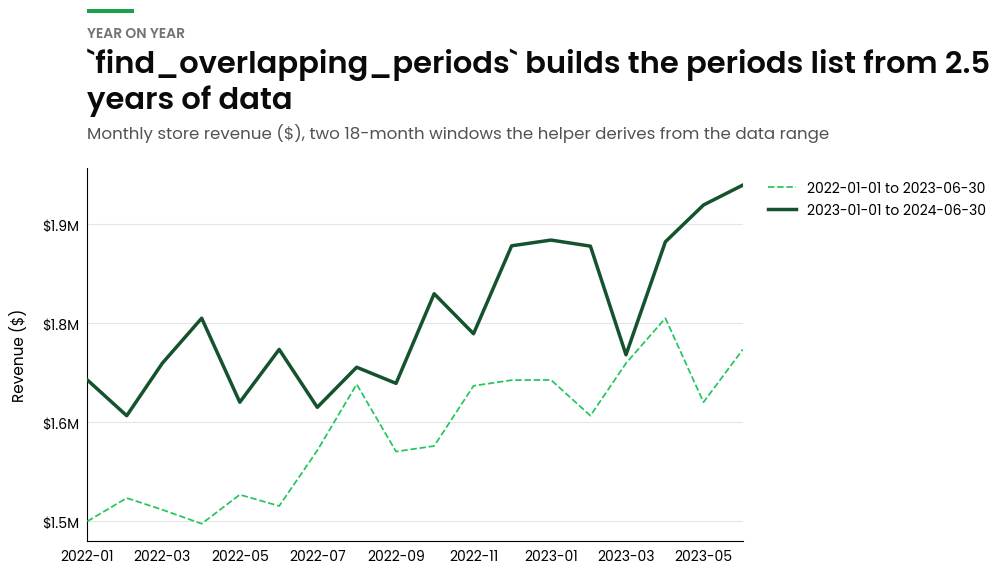

In [ ]:
periods = find_overlapping_periods("2022-01-01", "2024-06-30")
# periods == [
#     ("2022-01-01", "2023-06-30"),
#     ("2023-01-01", "2024-06-30"),
# ]

ax = period_on_period.plot(
    monthly_revenue,
    x_col="date",
    value_col="monthly_revenue",
    periods=periods,
    eyebrow="Year on year",
    title="`find_overlapping_periods` builds the periods list from 2.5 years of data",
    subtitle="Monthly store revenue ($), two 18-month windows the helper derives from the data range",
    y_label="Revenue ($)",
    figsize=(10, 6),
    move_legend_outside=True,
)
set_axis_shorthand(ax.yaxis, prefix="$")
plt.show()

## End-of-Line Legend

Pass `legend_style="end_of_line"` to drop the boxed legend and place each period's label at the right end of its line in matching color. Because every line in a period-on-period chart ends at the same realigned x position, the labels are bumped apart vertically by their final y values, with thin leaders connecting each label back to its line end.

---

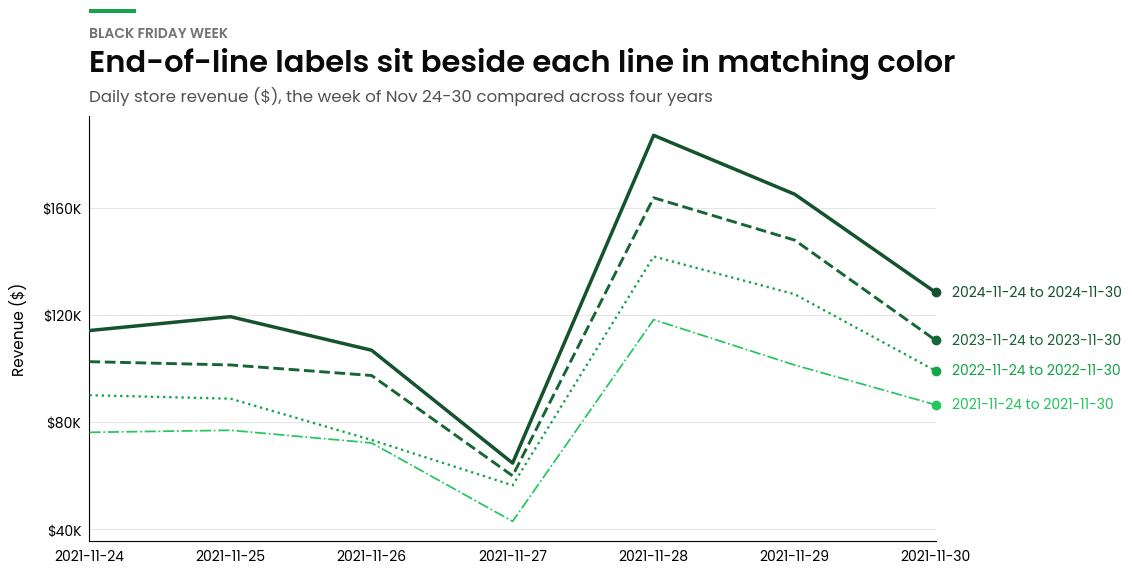

In [ ]:
ax = period_on_period.plot(
    bf_week_revenue,
    x_col="date",
    value_col="daily_revenue",
    periods=[
        ("2021-11-24", "2021-11-30"),
        ("2022-11-24", "2022-11-30"),
        ("2023-11-24", "2023-11-30"),
        ("2024-11-24", "2024-11-30"),
    ],
    legend_style="end_of_line",
    eyebrow="Black Friday week",
    title="End-of-line labels sit beside each line in matching color",
    subtitle="Daily store revenue ($), the week of Nov 24-30 compared across four years",
    y_label="Revenue ($)",
    figsize=(10, 6),
)
set_axis_shorthand(ax.yaxis, prefix="$")
plt.show()